In [1]:
%load_ext autoreload
%autoreload 2

# Building Similar Groups

Goal: maximize the similarity of clients assigned to a group.  

In [20]:
import pandas as pd


pd.set_option('display.max_columns', 50)

df = pd.read_csv('./data/data.csv')

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2556 entries, 0 to 2555
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Name                                   2556 non-null   str    
 1   Gender                                 2556 non-null   str    
 2   Age                                    2556 non-null   int64  
 3   City                                   2556 non-null   str    
 4   Working Professional or Student        2556 non-null   str    
 5   Profession                             1883 non-null   str    
 6   Academic Pressure                      502 non-null    float64
 7   Work Pressure                          2054 non-null   float64
 8   CGPA                                   502 non-null    float64
 9   Study Satisfaction                     502 non-null    float64
 10  Job Satisfaction                       2054 non-null   float64
 11  Sleep Duration 

## Data Preparation

### Creating a holdout set

Based on program descriptions on Charlie's website, it seems that patients can enroll on a rolling basis. This means that groups may need to accept new incoming patients. To accommodate this we'll separate the dataset into an initial set of current
patients (85%) and incoming patients (15%). Then, we will build feature vectors fitted on the initial set and then use that to generate features for both the initial and incoming before modeling.



In [22]:
from sklearn.model_selection import train_test_split
from modeling.vectorizer import FeatureConfig, Vectorizer

initial_set, newcomer_set = train_test_split(df, test_size=.15, random_state=True, shuffle=True)
print('Initial Set:', len(initial_set))
print('Newcomer Set:', len(newcomer_set))

Initial Set: 2172
Newcomer Set: 384


### Feature Engineering

The Vectorizer class creates feature vectors that are ready for model consumption handling data cleaning, feature engineering and encoding. Using FeatureConfig, users can pass what features they'd like to test into the vectorizer.

In [23]:
numeric_feats = [
    'age',
    'sleep_duration',
    'workstudy_hours',
    'financial_stress',
    'pressure',
    'satisfaction',
    'dietary_enc',
    'unhealthy_diet',
    'education_level',
    'city_lat',
    'city_lon',
    'stress_index',
    'wellbeing_score',
    'worklife_balance',
]

categorical_feats = [
    'city',
    'profession_category',
    'age_group',
    'cgpa_band'
]

boolean_feats = [
    'gender_enc',
    'family_history',
    'depression',
    'suicidal_thoughts',
    'is_professional',
    'high_risk',
]

config = FeatureConfig(numeric_feats, categorical_feats, boolean_feats)

vec = Vectorizer(config)

vec.fit(initial_set)
init_vecs = vec.transform(initial_set)
newcomer_vecs = vec.transform(newcomer_set)

print('Initial Set:', len(initial_set))
print('Newcomer Set:', len(newcomer_set))

Initial Set: 2172
Newcomer Set: 384


In [24]:
init_vecs.head()

,numeric__age,numeric__sleep_duration,numeric__workstudy_hours,numeric__financial_stress,numeric__pressure,numeric__satisfaction,numeric__dietary_enc,numeric__unhealthy_diet,numeric__education_level,numeric__city_lat,numeric__city_lon,numeric__stress_index,numeric__wellbeing_score,numeric__worklife_balance,categorical__city_Agra,categorical__city_Ahmedabad,categorical__city_Bangalore,categorical__city_Bhopal,categorical__city_Chennai,categorical__city_Delhi,categorical__city_Faridabad,categorical__city_Ghaziabad,categorical__city_Hyderabad,categorical__city_Indore,categorical__city_Jaipur,...,categorical__profession_category_Education,categorical__profession_category_Engineering,categorical__profession_category_Finance,categorical__profession_category_Healthcare,categorical__profession_category_Legal,categorical__profession_category_Management,categorical__profession_category_Other,categorical__profession_category_Student,categorical__profession_category_Technology,categorical__age_group_23-30,categorical__age_group_31-40,categorical__age_group_41-50,categorical__age_group_51+,categorical__age_group_≤22,categorical__cgpa_band_5-6,categorical__cgpa_band_6-7,categorical__cgpa_band_7-8,categorical__cgpa_band_8+,categorical__cgpa_band_non_student,boolean__gender_enc,boolean__family_history,boolean__depression,boolean__suicidal_thoughts,boolean__is_professional,boolean__high_risk
patient_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1827,1.622423,-1.336989,-0.823656,0.021134,1.406759,1.398419,0.010609,-0.724763,0.820039,-1.997770,0.784274,1.529692,0.251237,0.016078,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,0,1,0
1846,0.482318,-1.336989,0.242324,-0.685075,0.700779,-0.719689,1.223339,-0.724763,0.820039,0.025602,0.091965,0.658790,-0.755565,-1.220048,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1,0,1,1,1
2007,-1.553585,-1.336989,-0.024171,-1.391283,0.700779,-0.719689,-1.202121,1.379762,-1.840342,0.737449,0.944646,0.223339,-1.762368,-0.911017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,1,1,0,1,0
368,1.459551,1.354336,0.775314,0.727343,0.700779,-1.425724,1.223339,-0.724763,-0.510151,-0.393731,0.497490,0.223339,0.251237,0.943172,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,0,1,1,0
1164,0.482318,0.457228,1.041809,1.433552,1.406759,-0.013653,-1.202121,1.379762,-0.510151,0.025602,0.091965,1.529692,-0.252164,-0.086933,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,1,1,1,1


## Baseline Model: Random Groups

To get a baseline for which to improve from let's create random groups of 12 and evaluate cluster similarity using WCSS and Silhouette. BaselineGroupModel contains the random choice behavior and Evaluator provides helper functions to evaluate the model (metrics, plots, etc)

In [25]:
from modeling.agglomerative_clustering import AggloGroupModel
from modeling.baseline import BaselineGroupModel
from modeling.evaluate import Evaluator

In [26]:
base_model = BaselineGroupModel()
base_model.fit(init_vecs)
base_groups = base_model.predict(initial_set)
initial_set['base_group_assignment'] = base_groups.astype(str)
base_eval = Evaluator(base_model)

In [28]:
#generate readable vectors for analysis
init_feats = vec.pipeline.steps[0][1].transform(initial_set)
init_feats.head()

,gender,age,city,status,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,workstudy_hours,financial_stress,family_history,depression,base_group_assignment,pressure,satisfaction,pressure_source,sleep_duration_raw,gender_enc,is_professional,dietary_enc,unhealthy_diet,education_level,profession_category,city_lat,city_lon,stress_index,wellbeing_score,physical_score,emotional_score,age_group,worklife_balance,high_risk,cgpa_band,treatment_not_needed
patient_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1827,Female,59,Chennai,Working Professional,Doctor,NaN,5.0,NaN,NaN,5.0,1,Moderate,M.Pharm,0,3,3,0,0,45,5.0,5.0,work,Less than 5 hours,0,1,1,0,2,Healthcare,13.083694,80.270186,4.000000,2.333333,2.5,1.25,51+,0.750000,0,non_student,False
1846,Male,45,Bhopal,Working Professional,Entrepreneur,NaN,4.0,NaN,NaN,2.0,1,Healthy,MSc,1,7,2,1,0,155,4.0,2.0,work,Less than 5 hours,1,1,2,0,2,Management,23.258486,77.401989,3.333333,1.666667,3.0,3.00,41-50,0.416667,1,non_student,False
2007,Male,20,Lucknow,Working Professional,NaN,NaN,4.0,NaN,NaN,2.0,1,Unhealthy,Class 12,0,6,1,1,1,91,4.0,2.0,work,Less than 5 hours,1,1,0,1,0,Other,26.838100,80.934600,3.000000,1.000000,2.0,2.75,≤22,0.500000,0,non_student,False
368,Female,57,Nagpur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,4,Healthy,B.Ed,1,9,4,1,0,175,4.0,1.0,work,More than 8 hours,0,1,2,0,1,Education,21.149813,79.082056,3.000000,2.333333,1.5,3.25,51+,1.000000,0,non_student,False
1164,Female,45,Bhopal,Working Professional,Teacher,NaN,5.0,NaN,NaN,3.0,3,Unhealthy,B.Ed,1,10,5,1,1,107,5.0,3.0,work,7-8 hours,0,1,0,1,1,Education,23.258486,77.401989,4.000000,2.000000,1.0,4.00,41-50,0.722222,1,non_student,False


We now have a baseline score to improve from. 
- There are 181 groups of 12 with a mean WCSS of 2039. 
- The negative silhouette score here implies that there are group members who perhaps do not belong to their assigned cluster, which makes sense for a random assignment. 
- We should aim in subsequent experiments to minimize WCSS and to aim for a silhouette of slightly above zero (there will be natural overlap between classes due to the 12 person cap, but we should have some separation from other groups) 
- Very little cohesion in groups

In [85]:
print(base_eval.report(initial_set, init_feats))


Metrics report:
  Groups:     181
  Sizes:      min=12  max=12  mean=12.0  std=0.0  cv=0.000
  WCSS:       total=369070.91 mean= 2039.07
  Silhouette: -0.3471  (metric=euclidean)
  Cohesion:   % of groups that are homogeneous
    uniform gender             0.0%
    uniform status             9.9%
    uniform city               0.0%
    age range ≤10yr            0.0%
    uniform diet               0.6%
    uniform profession         0.0%
    uniform depression         8.3%
    uniform suicidal           0.0%
    uniform high_risk          2.2%
    uniform treatment not needed 58.0%


## Agglomerative Clustering

Use agglomerative clustering to build similar groups based on feature vectors. If a group exceeds the max group size of 12, rerun agglomerative clustering within the group until it is below 12

In [30]:
agglo_model = AggloGroupModel()
agglo_model.fit(init_vecs)
agglo_groups = agglo_model.predict(init_vecs)
initial_set['agglo_group_assignment'] = agglo_groups.astype(str)
agglo_eval = Evaluator(agglo_model)

The total number of clusters has risen due to agglomerative clustering finding smaller groups.

In [31]:
initial_set.agglo_group_assignment.describe()

count     2172
unique     264
top        123
freq        12
Name: agglo_group_assignment, dtype: object

Text(0, 0.5, 'Number of Groups')

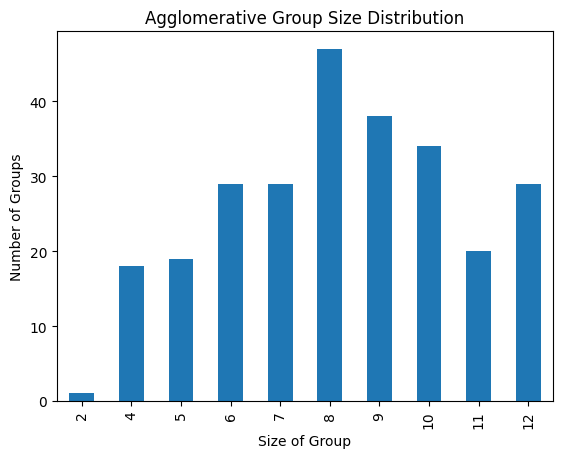

In [55]:
import matplotlib.pyplot as plt
fig = initial_set.agglo_group_assignment.value_counts().value_counts().sort_index().plot.bar()
plt.title("Agglomerative Group Size Distribution")
plt.xlabel('Size of Group')
plt.ylabel('Number of Groups')


Nice! We've improved on the WCSS and Silhouette a lot!
- Total number of groups has gone up. We need to beware of this growing to fast to considering a) therapist/personnel capacity and b) Many small groups (2/3 people) may not be optimal
- We're down to mean WCSS of 50.67 and silouette is positive and near zero
- Cohesion is also much better than random selection, although we could probably improve this particularly on suicidal and perhaps age

In [84]:
print(agglo_eval.report(init_vecs, init_feats))

Metrics report:
  Groups:     264
  Sizes:      min=2  max=12  mean=8.2  std=2.3  cv=0.284
  WCSS:       total=13375.97 mean= 50.67
  Silhouette: 0.0623  (metric=euclidean)
  Cohesion:   % of groups that are homogeneous
    uniform gender             6.8%
    uniform status             75.4%
    uniform city               2.7%
    age range ≤10yr            35.6%
    uniform diet               98.1%
    uniform profession         11.7%
    uniform depression         67.0%
    uniform suicidal           9.1%
    uniform high_risk          56.4%
    uniform treatment not needed 85.2%


Let's see what the makeup of these clusters look like:

Observations from manual inspection of groups
- When there is an outlier on age, there they often match in other ways
- City/physical location seem to be secondary (some clusters are more uniform than others)

In [39]:
agglo_eval.print_clusters(init_feats, max_rows=12)

── Cluster 0  (10 members) ──────────────────────────────────────────────────
  Age          mean=48.8  (range 43–58)
  Status       100% Professional  0% Student
  Risk         high_risk=100%  depression=20%  suicidal=30%
  Scores       stress=4.00  wellbeing=0.90  worklife=0.75
  Stressors    pressure=4.2  financial=4.0  sleep=1.2

            age  gender         city                status  profession_category dietary_habits  education_level  stress_index  high_risk  depression  suicidal_thoughts  family_history  pressure  satisfaction  sleep_duration  financial_stress
patient_id                                                                                                                                                                                                                                       
1453         58  Female       Nashik  Working Professional            Education      Unhealthy                2      4.333333          1           0                  0             

## Experiment: Weighted Agglomerative Clustering

Upweight clinical severity features before clustering so patients with similar mental health profiles are pulled closer together in the distance metric. All other features default to weight 1.0. Column names use the vectorizer's `numeric__` prefix.

| Feature | Weight |
|---|---|
| depression, suicidal_thoughts | 3× |
| stress_index, unhealthy_diet | 2.0× |
| financial_stress, wellbeing_score, pressure, family_history, statisfaction | 1.5× |

In [53]:
# Feature weights use the vectorizer's prefixed column names (numeric__<feature>)
clinical_weights = {
    "numeric__depression":        5.0,
    "numeric__suicidal_thoughts": 5.0,
    "numeric__stress_index":      2.0,
    # "numeric__unhealthy_diet":    2.0, #took out this because its already doing well
    "numeric__financial_stress":  1.5,
    "numeric__wellbeing_score":   1.5,
    "numeric__pressure":          1.5,
    "numeric__family_history":    1.5,
    "numeric__satisfaction":      1.5
}

weighted_model = AggloGroupModel(group_size=12, feature_weights=clinical_weights)
weighted_model.fit(init_vecs)
weighted_groups = weighted_model.predict(init_vecs)
initial_set['weighted_group_assignment'] = weighted_groups.astype(str)
weighted_eval = Evaluator(weighted_model)

Hmmm we lowered WCSS a tad bit, but cohesion decreased across most attributes except high risk. Perhaps that's because the weighted model produced smaller clusters instead of actually improving the similarity of the clusters themselves.

In [54]:
print(weighted_eval.report(init_vecs, init_feats))

Metrics report:
  Groups:     274
  Sizes:      min=3  max=12  mean=7.9  std=2.3  cv=0.289
  WCSS:       total=13711.73 mean= 50.04
  Silhouette: 0.0465  (metric=euclidean)
  Cohesion:   % of groups that are homogeneous
    uniform gender             6.2%
    uniform status             69.0%
    uniform city               0.7%
    age range ≤10yr            23.4%
    uniform diet               95.3%
    uniform profession         9.5%
    uniform depression         63.1%
    uniform suicidal           8.4%
    uniform high_risk          62.4%


Text(0, 0.5, 'Number of Groups')

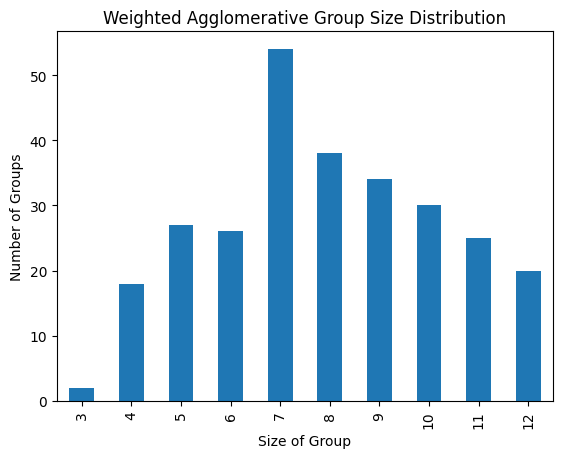

In [57]:
import matplotlib.pyplot as plt
fig = initial_set.weighted_group_assignment.value_counts().value_counts().sort_index().plot.bar()
plt.title("Weighted Agglomerative Group Size Distribution")
plt.xlabel('Size of Group')
plt.ylabel('Number of Groups')


In [77]:
weighted_eval.print_clusters(init_feats)

── Cluster 0  (7 members) ──────────────────────────────────────────────────
  Age          mean=52.9  (range 42–58)
  Status       100% Professional  0% Student
  Risk         high_risk=57%  depression=0%  suicidal=43%
  Scores       stress=3.48  wellbeing=2.62  worklife=0.62
  Stressors    pressure=2.3  financial=4.7  sleep=1.6

            age  gender         city                status profession_category dietary_habits  education_level  stress_index  high_risk  depression  suicidal_thoughts  family_history  pressure  satisfaction  sleep_duration  financial_stress  treatment_not_needed
patient_id                                                                                                                                                                                                                                                            
236          58  Female    Bangalore  Working Professional               Other       Moderate                0      3.666667          1      

## Experiment: k-NN Connectivity Agglomerative Clustering

Constrain the linkage graph using `kneighbors_graph` so only locally similar patients (nearest neighbors in feature space) can be directly merged. This reduces the "chaining" artifact where ward linkage can bridge distant clusters through a long chain of intermediate points.

In [62]:
from sklearn.neighbors import kneighbors_graph

knn_conn = kneighbors_graph(init_vecs, n_neighbors=12, include_self=False)

knn_model = AggloGroupModel(group_size=12, connectivity=knn_conn)
knn_model.fit(init_vecs)
knn_groups = knn_model.predict(init_vecs)
initial_set['knn_conn_group_assignment'] = knn_groups.astype(str)
knn_eval = Evaluator(knn_model)

In [63]:
print(knn_eval.report(init_vecs, init_feats))

Metrics report:
  Groups:     265
  Sizes:      min=2  max=12  mean=8.2  std=2.3  cv=0.283
  WCSS:       total=13363.34 mean= 50.43
  Silhouette: 0.0630  (metric=euclidean)
  Cohesion:   % of groups that are homogeneous
    uniform gender             7.2%
    uniform status             75.5%
    uniform city               2.3%
    age range ≤10yr            35.5%
    uniform diet               98.1%
    uniform profession         11.3%
    uniform depression         66.8%
    uniform suicidal           9.8%
    uniform high_risk          56.2%


## Experiment: Demographic Attribute-Matched Connectivity

Build a custom sparse connectivity matrix where two patients are only eligible for direct merging if they share the same **student/professional status**, **age group**, and **gender**. This enforces demographic cohesion as a hard structural constraint (not just a soft feature signal), keeping the agglomerative algorithm from bridging across demographic boundaries.

In [ ]:
import scipy.sparse as sp
import numpy as np

# Build connectivity from preprocessed (pre-vectorization) features
attrs = init_feats[['is_professional', 'age_group', 'gender_enc']].copy().reset_index(drop=True)
attrs['_pos'] = np.arange(len(attrs))

# Vectorized: find all pairs sharing status + age_group + gender
pairs = attrs.merge(attrs, on=['is_professional', 'age_group', 'gender_enc'], suffixes=('_i', '_j'))
pairs = pairs[pairs['_pos_i'] != pairs['_pos_j']]

rows, cols = pairs['_pos_i'].values, pairs['_pos_j'].values
attr_conn = sp.csr_matrix(
    (np.ones(len(rows), dtype=np.float32), (rows, cols)),
    shape=(len(attrs), len(attrs))
)

print(f"Connectivity matrix: {attr_conn.shape}, nnz={attr_conn.nnz:,}")

attr_conn_model = AggloGroupModel(group_size=12, connectivity=attr_conn)
attr_conn_model.fit(init_vecs)
attr_conn_groups = attr_conn_model.predict(init_vecs)
initial_set['attr_conn_group_assignment'] = attr_conn_groups.astype(str)
attr_conn_eval = Evaluator(attr_conn_model)

Connectivity matrix: (2172, 2172), nnz=399,586


Enforcing connectivity was really effective in boosting cohesion amongst demographic attributes. WCSS rose a bit, but it perhaps is a good trade off if demographically similar groups make better groups. 

In [78]:
print(attr_conn_eval.report(init_vecs, init_feats))

Metrics report:
  Groups:     278
  Sizes:      min=2  max=12  mean=7.8  std=2.5  cv=0.315
  WCSS:       total=15284.42 mean= 54.98
  Silhouette: 0.0089  (metric=euclidean)
  Cohesion:   % of groups that are homogeneous
    uniform gender             84.9%
    uniform status             93.2%
    uniform city               1.1%
    age range ≤10yr            84.9%
    uniform diet               86.7%
    uniform profession         19.1%
    uniform depression         66.5%
    uniform suicidal           7.9%
    uniform high_risk          48.6%
    uniform treatment not needed 80.6%


Text(0, 0.5, 'Number of Groups')

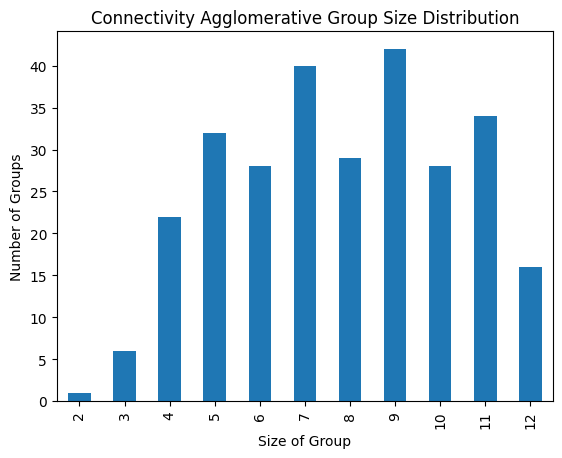

In [69]:
import matplotlib.pyplot as plt
fig = initial_set.attr_conn_group_assignment.value_counts().value_counts().sort_index().plot.bar()
plt.title("Connectivity Agglomerative Group Size Distribution")
plt.xlabel('Size of Group')
plt.ylabel('Number of Groups')

## Experiment: Clinical + Demographic Attribute-Matched Connectivity

Build a custom sparse connectivity matrix where two patients are only eligible for direct merging if they share the values **student/professional status**, **age group**, **suicidal thoughts**. This enforces demographic cohesion as a hard structural constraint (not just a soft feature signal), keeping the agglomerative algorithm from bridging across demographic boundaries.

In [82]:
import scipy.sparse as sp
import numpy as np

# Build connectivity from preprocessed (pre-vectorization) features
connectivity_attrs = [
    'is_professional',
    'age_group',
    'suicidal_thoughts', 
    'treatment_not_needed',
    'unhealthy_diet', 
    'depression'
]
attrs = init_feats[connectivity_attrs].copy().reset_index(drop=True)
attrs['_pos'] = np.arange(len(attrs))

# Vectorized: find all pairs sharing status + age_group + gender
pairs = attrs.merge(attrs, on=connectivity_attrs, suffixes=('_i', '_j'))
pairs = pairs[pairs['_pos_i'] != pairs['_pos_j']]

rows, cols = pairs['_pos_i'].values, pairs['_pos_j'].values
attr_conn = sp.csr_matrix(
    (np.ones(len(rows), dtype=np.float32), (rows, cols)),
    shape=(len(attrs), len(attrs))
)

print(f"Connectivity matrix: {attr_conn.shape}, nnz={attr_conn.nnz:,}")

clinit_attr_conn_model = AggloGroupModel(group_size=12, connectivity=attr_conn)
clinit_attr_conn_model.fit(init_vecs)
clinit_attr_conn_groups = clinit_attr_conn_model.predict(init_vecs)
initial_set['clinic_attr_conn_group_assignment'] = clinit_attr_conn_groups.astype(str)
clinit_attr_conn_eval = Evaluator(clinit_attr_conn_model)

Connectivity matrix: (2172, 2172), nnz=178,000


In [83]:
print(clinit_attr_conn_eval.report(init_vecs, init_feats))

Metrics report:
  Groups:     272
  Sizes:      min=2  max=12  mean=8.0  std=2.5  cv=0.319
  WCSS:       total=14794.03 mean= 54.39
  Silhouette: 0.0226  (metric=euclidean)
  Cohesion:   % of groups that are homogeneous
    uniform gender             7.0%
    uniform status             76.8%
    uniform city               1.8%
    age range ≤10yr            67.3%
    uniform diet               94.1%
    uniform profession         12.9%
    uniform depression         74.3%
    uniform suicidal           54.4%
    uniform high_risk          56.2%
    uniform treatment not needed 89.7%
